# Proyecto Final - Mantenimiento Predictivo con Deep Learning

## 1. Planteamiento del Problema

Las fallas operativas en equipos industriales pueden generar paradas no programadas, pérdidas económicas significativas y riesgos para la seguridad.

El mantenimiento predictivo permite anticipar estas fallas mediante el análisis de datos operativos.

## 2. Objetivo

Desarrollar un modelo de deep learning capaz de predecir fallas operativas utilizando variables de proceso, con el fin de apoyar la toma de decisiones en mantenimiento.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

## 3. Dataset

Se utiliza el **AI4I 2020 Predictive Maintenance Dataset**, un conjunto de datos diseñado para la predicción de fallas en equipos industriales.

### Variables principales:
- Tipo de máquina
- Temperatura del aire
- Temperatura del proceso
- Velocidad de rotación
- Torque
- Desgaste de herramienta

### Variable objetivo:
- Machine failure (0 = No falla, 1 = Falla)

In [24]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [26]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [27]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Machine failure
0    9661
1     339
Name: count, dtype: int64


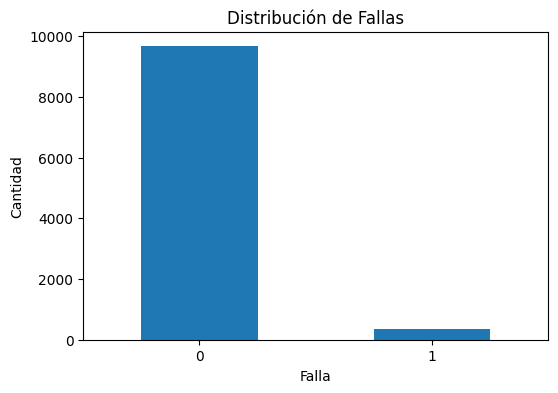

In [28]:
failure_counts = df["Machine failure"].value_counts()

print(failure_counts)

plt.figure(figsize=(6,4))
failure_counts.plot(kind="bar")
plt.title("Distribución de Fallas")
plt.xlabel("Falla")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

Se observa que el dataset se encuentra desbalanceado, con una menor cantidad de eventos de falla en comparación con los casos normales. Este comportamiento es común en escenarios reales de mantenimiento predictivo.

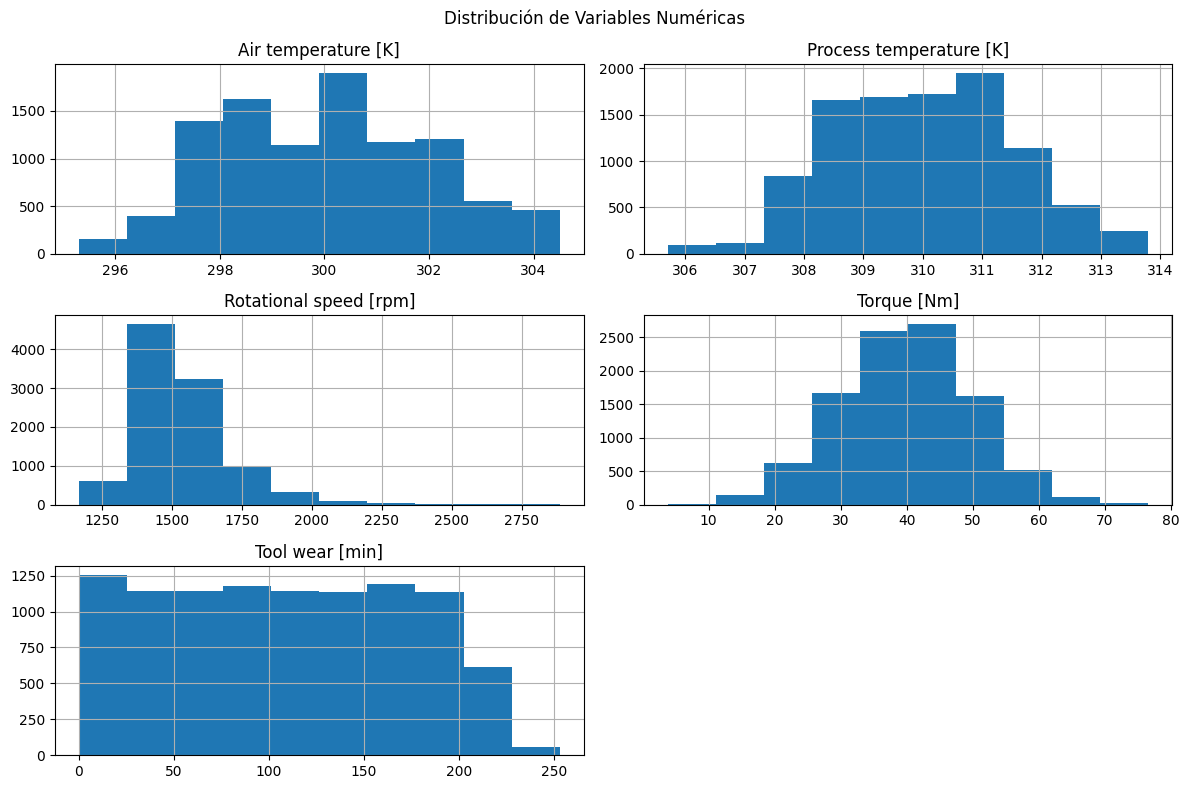

In [29]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numeric_cols].hist(figsize=(12,8))
plt.suptitle("Distribución de Variables Numéricas")
plt.tight_layout()
plt.show()

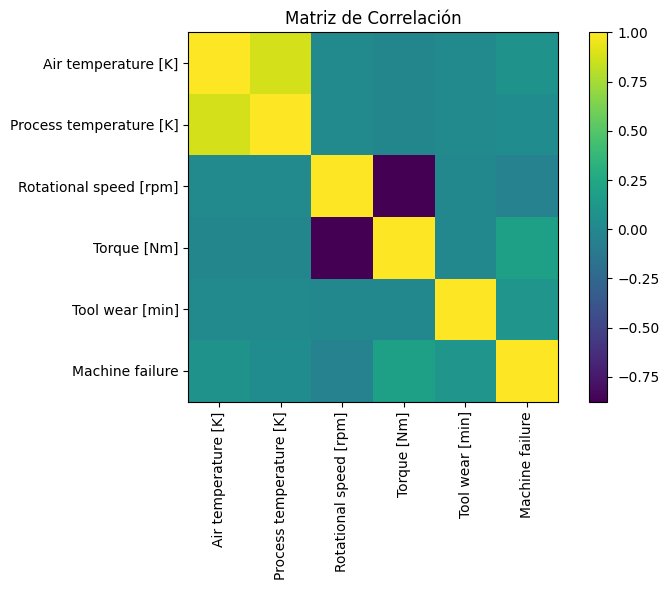

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


In [30]:
corr = df[numeric_cols + ["Machine failure"]].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

corr

## 4. Preprocesamiento de Datos

Se realizan los siguientes pasos:

1. Eliminación de variables no relevantes.
2. Codificación de variables categóricas.
3. Separación de variables predictoras y variable objetivo.
4. División en conjunto de entrenamiento y prueba.
5. Escalamiento de variables numéricas.

In [31]:
df_model = df.drop(columns=["UDI", "Product ID"])

le = LabelEncoder()
df_model["Type"] = le.fit_transform(df_model["Type"])

X = df_model.drop(columns=["Machine failure",
                           "TWF", "HDF", "PWF", "OSF", "RNF"], errors="ignore")
y = df_model["Machine failure"]

X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,2,298.1,308.6,1551,42.8,0
1,1,298.2,308.7,1408,46.3,3
2,1,298.1,308.5,1498,49.4,5
3,1,298.2,308.6,1433,39.5,7
4,1,298.2,308.7,1408,40.0,9


Las variables TWF, HDF, PWF, OSF y RNF representan tipos específicos de falla. Estas se excluyen del modelo para evitar "data leakage", ya que están directamente relacionadas con el evento de falla.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5.1 Modelo Base (Baseline)

Antes de implementar el modelo de deep learning, se construye un modelo base utilizando regresión logística. Esto permite establecer un punto de comparación y evaluar si el modelo neuronal realmente aporta valor.

In [34]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)

print("Baseline Logistic Regression")
print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Recall:", recall_score(y_test, baseline_pred))
print("F1:", f1_score(y_test, baseline_pred))

Baseline Logistic Regression
Accuracy: 0.968
Recall: 0.11764705882352941
F1: 0.2


## 5. Modelo de Deep Learning

Se implementa una red neuronal tipo Multi-Layer Perceptron (MLP) para resolver el problema de clasificación binaria.

In [35]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9531 - loss: 0.2635 - val_accuracy: 0.9656 - val_loss: 0.1622
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9663 - loss: 0.1664 - val_accuracy: 0.9656 - val_loss: 0.1394
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9664 - loss: 0.1389 - val_accuracy: 0.9656 - val_loss: 0.1253
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9656 - loss: 0.1287 - val_accuracy: 0.9669 - val_loss: 0.1170
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9678 - loss: 0.1210 - val_accuracy: 0.9675 - val_loss: 0.1121
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9678 - loss: 0.1153 - val_accuracy: 0.9688 - val_loss: 0.1074
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9697 - loss: 0.1103 - val_accuracy: 0.9688 - val_loss: 0.1062
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9694 - loss: 0.1045 - val_accuracy: 0.

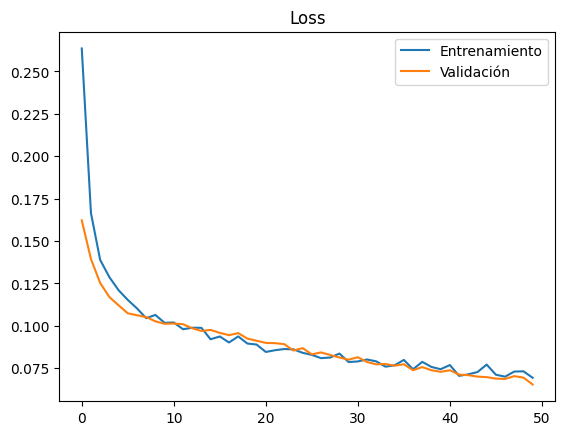

In [37]:
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title("Loss")
plt.legend()
plt.show()

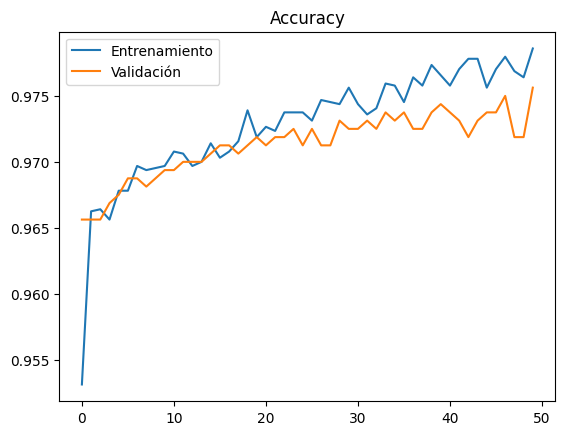

In [38]:
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title("Accuracy")
plt.legend()
plt.show()

In [39]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.977
Precision: 0.8928571428571429
Recall: 0.36764705882352944
F1: 0.5208333333333334


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.89      0.37      0.52        68

    accuracy                           0.98      2000
   macro avg       0.94      0.68      0.75      2000
weighted avg       0.98      0.98      0.97      2000



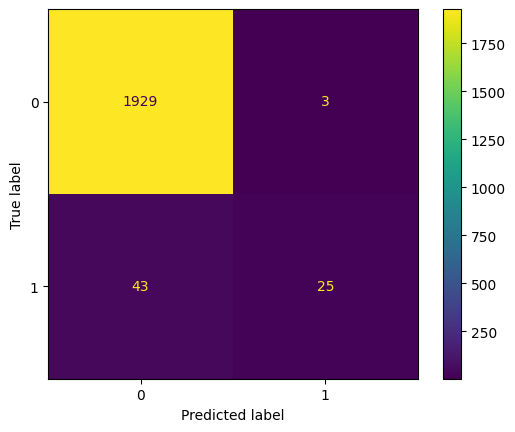

In [41]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [42]:
results_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1"],
    "Valor": [accuracy, precision, recall, f1]
})

results_df

,Métrica,Valor
0,Accuracy,0.977000
1,Precision,0.892857
2,Recall,0.367647
3,F1,0.520833


## 6. Interpretación de Resultados

Si bien el modelo presenta un buen desempeño general, es importante considerar el desbalance del dataset.

En este tipo de problemas, el recall es una métrica clave, ya que permite evaluar la capacidad del modelo para detectar fallas reales. No identificar una falla puede generar impactos significativos en la operación.

El modelo logra capturar patrones relevantes en los datos operativos, lo que evidencia el potencial del deep learning en aplicaciones de mantenimiento predictivo.

## 7. Valor para la Toma de Decisiones

Este modelo puede ser aplicado en entornos industriales para:

- anticipar fallas operativas
- reducir tiempos de inactividad
- optimizar programas de mantenimiento
- mejorar la confiabilidad de los activos
- reducir riesgos operacionales y ambientales

En sectores como energía e hidrocarburos, este tipo de soluciones puede generar un impacto significativo en eficiencia y seguridad.

## 8. Conclusiones

Se desarrolló un modelo de deep learning capaz de predecir fallas operativas a partir de variables de operación.

Los resultados demuestran que es posible utilizar redes neuronales para apoyar estrategias de mantenimiento predictivo.

Como mejoras futuras se propone:

- balanceo de clases
- optimización de hiperparámetros
- comparación con otros modelos
- implementación en sistemas en tiempo real

Este tipo de modelos puede aplicarse directamente en industrias como petróleo, gas y energía, donde la confiabilidad operativa es crítica.

La implementación de soluciones de mantenimiento predictivo permite reducir costos de mantenimiento, minimizar paradas no programadas y mejorar la seguridad operacional.